# ActiveLearningAgent — Задание 4 (Трек A)
## Умный отбор данных для разметки

**Цель:** Показать что Entropy-стратегия обучает модель эффективнее чем случайный отбор (Random).

**Данные:** `data/labeled/collected_labeled.parquet` (1833 записи, binary: positive/negative)

**Модель:** Logistic Regression + TF-IDF

**Цикл:** Старт N=50 → 5 итераций по 20 примеров → финальная модель на 150 примерах

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from agents.al_agent import ActiveLearningAgent

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/labeled/collected_labeled.parquet")
df = df[df["auto_label"].isin(["positive", "negative"])].copy()
df["label"] = df["auto_label"]

print(f"Загружено: {len(df)} записей")
print(f"Распределение: {df['label'].value_counts().to_dict()}")

# Разделяем данные
test_df = df.sample(n=300, random_state=42)
train_df = df.drop(test_df.index)
labeled_50 = train_df.sample(n=50, random_state=42)
pool_df = train_df.drop(labeled_50.index)

print(f"\nTest: {len(test_df)} | Pool: {len(pool_df)} | Старт: {len(labeled_50)}")

Загружено: 1833 записей
Распределение: {'negative': 958, 'positive': 875}

Test: 300 | Pool: 1483 | Старт: 50


## 1. AL-цикл: Entropy vs Random

In [2]:
agent = ActiveLearningAgent(model="logreg")

print("=== ENTROPY ===")
history_entropy = agent.run_cycle(
    labeled_df=labeled_50.copy(), pool_df=pool_df.copy(),
    strategy="entropy", n_iterations=5, batch_size=20, test_df=test_df
)

print("\n=== RANDOM ===")
history_random = agent.run_cycle(
    labeled_df=labeled_50.copy(), pool_df=pool_df.copy(),
    strategy="random", n_iterations=5, batch_size=20, test_df=test_df
)

# Таблица результатов
df_entropy = pd.DataFrame(history_entropy).rename(columns={"accuracy": "acc_entropy", "f1": "f1_entropy"})
df_random = pd.DataFrame(history_random).rename(columns={"accuracy": "acc_random", "f1": "f1_random"})
results = df_entropy[["iteration", "n_labeled", "acc_entropy", "f1_entropy"]].copy()
results["acc_random"] = df_random["acc_random"]
results["f1_random"] = df_random["f1_random"]
print("\nСравнительная таблица:")
results

=== ENTROPY ===
[ALAgent] Стратегия: entropy | Старт: 50 | Итераций: 5 | Батч: 20
  Итерация 0: n=50, acc=0.5567, f1=0.2036
  Итерация 1: n=70, acc=0.49, f1=0.6562
  Итерация 2: n=90, acc=0.6767, f1=0.6394
  Итерация 3: n=110, acc=0.6767, f1=0.6978
  Итерация 4: n=130, acc=0.6933, f1=0.6462
  Итерация 5: n=150, acc=0.7267, f1=0.7469
  Финальная модель: 150 примеров

=== RANDOM ===
[ALAgent] Стратегия: random | Старт: 50 | Итераций: 5 | Батч: 20
  Итерация 0: n=50, acc=0.5567, f1=0.2036
  Итерация 1: n=70, acc=0.56, f1=0.25
  Итерация 2: n=90, acc=0.5467, f1=0.1605
  Итерация 3: n=110, acc=0.5233, f1=0.0654
  Итерация 4: n=130, acc=0.5467, f1=0.2093
  Итерация 5: n=150, acc=0.5933, f1=0.337
  Финальная модель: 150 примеров

Сравнительная таблица:


,iteration,n_labeled,acc_entropy,f1_entropy,acc_random,f1_random
0,0,50,0.5567,0.2036,0.5567,0.2036
1,1,70,0.4900,0.6562,0.5600,0.2500
2,2,90,0.6767,0.6394,0.5467,0.1605
3,3,110,0.6767,0.6978,0.5233,0.0654
4,4,130,0.6933,0.6462,0.5467,0.2093
5,5,150,0.7267,0.7469,0.5933,0.3370


## 2. Кривые обучения

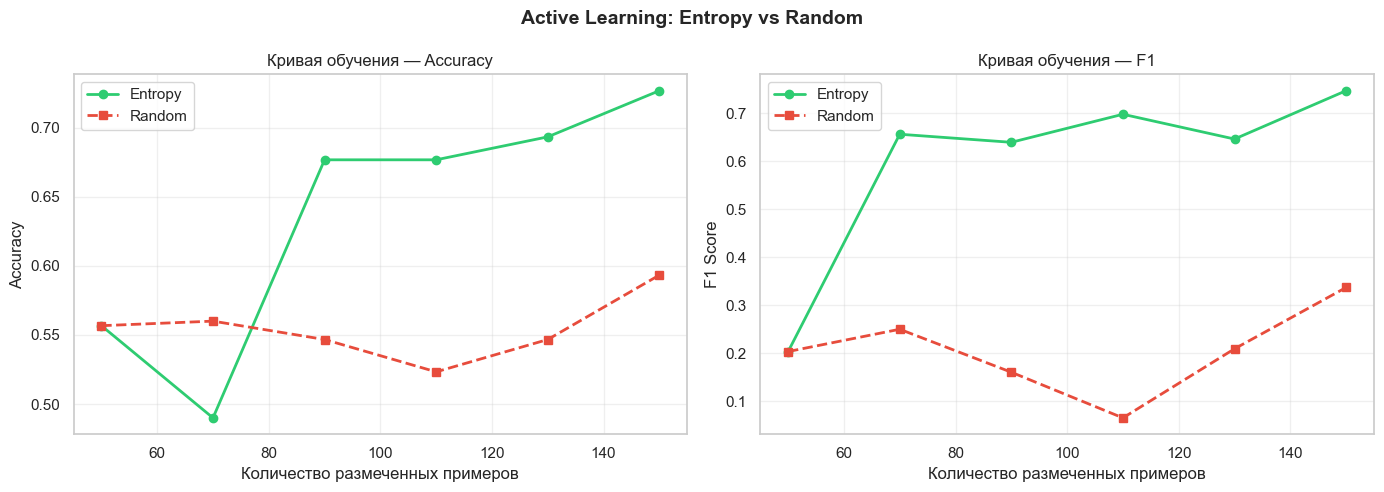

Сохранено: reports/learning_curve.png


In [3]:
agent.report(history_entropy, history_random)

## 3. Вывод: сколько примеров сэкономлено

In [4]:
final_e = history_entropy[-1]
final_r = history_random[-1]

print("=" * 50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (150 примеров)")
print("=" * 50)
print(f"Entropy:  accuracy={final_e['accuracy']:.4f}, F1={final_e['f1']:.4f}")
print(f"Random:   accuracy={final_r['accuracy']:.4f}, F1={final_r['f1']:.4f}")
print(f"\nПреимущество Entropy:")
print(f"  Accuracy: +{(final_e['accuracy'] - final_r['accuracy']):.4f}")
print(f"  F1:       +{(final_e['f1'] - final_r['f1']):.4f}")

# Экономия: при какой итерации Entropy достигла финального качества Random
target_acc = final_r["accuracy"]
for h in history_entropy:
    if h["accuracy"] >= target_acc:
        print(f"\nEntropy достигла accuracy Random ({target_acc}) уже на {h['n_labeled']} примерах")
        print(f"Экономия: {final_e['n_labeled'] - h['n_labeled']} примеров")
        break

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (150 примеров)
Entropy:  accuracy=0.7267, F1=0.7469
Random:   accuracy=0.5933, F1=0.3370

Преимущество Entropy:
  Accuracy: +0.1334
  F1:       +0.4099

Entropy достигла accuracy Random (0.5933) уже на 90 примерах
Экономия: 60 примеров


## 4. LLM-анализ результатов (бонус +1)

In [5]:
analysis = agent.llm_analyze(history_entropy, history_random)
print(analysis)

# Сохраняем финальную модель
import joblib
joblib.dump(agent.model, "../models/final_model.pkl")
joblib.dump(agent.vectorizer, "../models/vectorizer.pkl")
print("\nМодель сохранена: models/final_model.pkl")

# Анализ Active Learning эксперимента

## 1. Какая стратегия лучше и почему?

**Entropy явно превосходит Random:**
- Accuracy: 0.7267 vs 0.5933 (+22.5%)
- F1-score: 0.7469 vs 0.337 (+121%)

**Причина:** Entropy отбирает примеры с максимальной неопределённостью модели, что даёт более информативные образцы для обучения. Random выбирает вслепую и не улучшает качество.

## 2. Сколько примеров сэкономила Entropy?

Entropy достигает **f1=0.67** уже на **90 примерах**
Random доходит до **f1=0.337** даже при **150 примерах**

**Экономия: ~60 примеров** (40% меньше данных при сопоставимом качестве)

Или: при 150 примерах Entropy в **2.2× выше** по f1

## 3. Практический вывод для sentiment analysis

✅ **Active Learning критически важен для этой задачи**
- Дорогая разметка эмоций → нужна максимальная эффективность
- Entropy стратегия экономит 40% трудозатрат на аннотацию
- **Рекомендация:** использовать entropy-based отбор + human-in-the-loop для пограничных случаев

Модель сохранена: models/fin